# 🚀 YOLO26s — Local Training Notebook
> **Dataset:** Visual Inspection (door, extinguisher, gauge, person)  
> **Model:** YOLO26s (Ultralytics latest — NMS-free, MuSGD optimizer)  
> **Epochs:** 100 | **Save every:** 5 epochs | **imgsz:** 960  
> **Device:** `-1` (Idle GPU auto-selection) — [docs](https://docs.ultralytics.com/modes/train/#idle-gpu-training)  
> **Reference:** https://docs.ultralytics.com/models/yolo26/

---
### 📋 Notebook Contents
1. Environment & GPU Check  
2. Laptop Capability Assessment  
3. Dataset Exploration (EDA)  
4. Training YOLO26s  
5. Post-Training: Loss & Metric Curves  
6. Full Validation on Best Weights  
7. Class-wise Performance  
8. Confusion Matrix  
9. PR Curve & F1 Curve  
10. Testing on Test Split  
11. Visual Predictions (sample images)  
12. Training Summary & Comparison Card  
13. Resume Training (if interrupted)  
14. Output File Map  

---
## ⚙️ Cell 1 — Environment & GPU Check

In [3]:
import subprocess, sys, os
from pathlib import Path

# ── Auto-install / upgrade ultralytics if needed ──────────────
try:
    import ultralytics
    from packaging.version import Version
    if Version(ultralytics.__version__) < Version('8.4.0'):
        print('Upgrading ultralytics to support YOLO26...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        'ultralytics>=8.4.0'], check=True)
        import importlib; importlib.reload(ultralytics)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics>=8.4.0'], check=True)

import torch
from ultralytics import YOLO
import ultralytics

print('=' * 60)
print(f'  Python      : {sys.version.split()[0]}')
print(f'  PyTorch     : {torch.__version__}')
print(f'  Ultralytics : {ultralytics.__version__}')
print(f'  CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU         : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM        : {vram:.1f} GB')
    DEVICE = -1   # idle GPU auto-selection
else:
    print('  ⚠️  No CUDA GPU found — training on CPU (will be very slow!)')
    DEVICE = 'cpu'
print('=' * 60)

  Python      : 3.10.11
  PyTorch     : 2.11.0+cu128
  Ultralytics : 8.4.38
  CUDA        : True
  GPU         : NVIDIA GeForce RTX 5060 Laptop GPU
  VRAM        : 8.5 GB


---
## 💻 Cell 2 — Laptop Capability Assessment

In [4]:
import platform, psutil, math

print('=' * 60)
print('  LAPTOP / SYSTEM CAPABILITY CHECK')
print('=' * 60)

# ── CPU ───────────────────────────────────────────────────────
cpu_count   = psutil.cpu_count(logical=True)
cpu_physical= psutil.cpu_count(logical=False)
cpu_freq    = psutil.cpu_freq()
print(f'  OS          : {platform.system()} {platform.release()}')
print(f'  CPU cores   : {cpu_physical} physical / {cpu_count} logical')
if cpu_freq:
    print(f'  CPU freq    : {cpu_freq.current:.0f} MHz  (max {cpu_freq.max:.0f} MHz)')

# ── RAM ───────────────────────────────────────────────────────
ram = psutil.virtual_memory()
print(f'  RAM total   : {ram.total/1e9:.1f} GB')
print(f'  RAM avail   : {ram.available/1e9:.1f} GB  ({100-ram.percent:.0f}% free)')

# ── GPU ───────────────────────────────────────────────────────
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        vram_gb = props.total_memory / 1e9
        print(f'  GPU [{i}]      : {props.name}')
        print(f'  VRAM [{i}]     : {vram_gb:.1f} GB  (SM {props.major}.{props.minor})')

# ── Disk ──────────────────────────────────────────────────────
disk = psutil.disk_usage('C:\\')
print(f'  Disk free   : {disk.free/1e9:.1f} GB / {disk.total/1e9:.1f} GB')

# ── Training feasibility estimate ─────────────────────────────
print()
print('  YOLO26s Training Estimate (100 epochs, imgsz=960, batch=8)')
print('  ' + '-' * 55)
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram_gb >= 8:
        rec_batch = 8
        est_time  = '~2–4 hours'
        status    = '✅ GOOD'
    elif vram_gb >= 4:
        rec_batch = 4
        est_time  = '~4–8 hours'
        status    = '⚠️  OK (reduce batch=4)'
    else:
        rec_batch = 2
        est_time  = '~8–16 hours'
        status    = '⚠️  LOW VRAM (batch=2, imgsz=640)'
    print(f'  GPU status  : {status}')
    print(f'  Recommended : batch={rec_batch},  ~{est_time} for 100 epochs')
    print(f'  Device mode : -1  (idle GPU auto-selection)')
else:
    rec_batch = 4
    print(f'  ⚠️  CPU-only training: ~24–72 hours estimated for 100 epochs')
    print(f'  Tip: Consider Kaggle GPU (free T4/P100) for faster training')

print()
print('  YOLO26s Key advantages over YOLO11s:')
print('  • NMS-free end-to-end — faster inference')
print('  • MuSGD optimizer — better convergence')
print('  • Up to 43% faster CPU inference')
print('  • ProgLoss + STAL — better small-object detection')
print('=' * 60)

  LAPTOP / SYSTEM CAPABILITY CHECK
  OS          : Windows 10
  CPU cores   : 20 physical / 28 logical
  CPU freq    : 2100 MHz  (max 2100 MHz)
  RAM total   : 16.9 GB
  RAM avail   : 1.1 GB  (7% free)
  GPU [0]      : NVIDIA GeForce RTX 5060 Laptop GPU
  VRAM [0]     : 8.5 GB  (SM 12.0)
  Disk free   : 80.5 GB / 537.4 GB

  YOLO26s Training Estimate (100 epochs, imgsz=960, batch=8)
  -------------------------------------------------------
  GPU status  : ✅ GOOD
  Recommended : batch=8,  ~~2–4 hours for 100 epochs
  Device mode : -1  (idle GPU auto-selection)

  YOLO26s Key advantages over YOLO11s:
  • NMS-free end-to-end — faster inference
  • MuSGD optimizer — better convergence
  • Up to 43% faster CPU inference
  • ProgLoss + STAL — better small-object detection


---
## 📁 Cell 3 — Path Configuration

In [11]:
# ── Configure all paths ──────────────────────────────────────
WORK_DIR    = Path(r'C:\Users\Rebecca Fernando\Desktop\Dinethra\Yolov11s')
DATASET_DIR = Path(r'C:\Users\Rebecca Fernando\Desktop\Dinethra\YOLO_Final_Dataset')
DATA_YAML   = WORK_DIR / 'data_local.yaml'
RUN_DIR     = WORK_DIR / 'runs'
EXP_NAME    = 'yolo26s_exp'

WORK_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify dataset paths ─────────────────────────────────────
splits = ['train', 'valid', 'test']
print('Dataset verification:')
print('-' * 40)
for split in splits:
    img_dir = DATASET_DIR / split / 'images'
    lbl_dir = DATASET_DIR / split / 'labels'
    n_imgs = len(list(img_dir.glob('*.*'))) if img_dir.exists() else 0
    n_lbls = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f'  {split:6s} → images: {n_imgs:5d}  labels: {n_lbls:5d}')
print(f'  data.yaml exists: {DATA_YAML.exists()}')
print('-' * 40)
print(f'  Work dir   : {WORK_DIR}')
print(f'  Output dir : {RUN_DIR / EXP_NAME}')
print(f'  Model      : yolo26s.pt')
print(f'  Device     : -1  (idle GPU auto-selection)')

Dataset verification:
----------------------------------------
  train  → images:  3171  labels:  3171
  valid  → images:   630  labels:   630
  test   → images:   401  labels:   401
  data.yaml exists: True
----------------------------------------
  Work dir   : C:\Users\Rebecca Fernando\Desktop\Dinethra\Yolov11s
  Output dir : C:\Users\Rebecca Fernando\Desktop\Dinethra\Yolov11s\runs\yolo26s_exp
  Model      : yolo26s.pt
  Device     : -1  (idle GPU auto-selection)


---
## 🔬 Cell 4 — Dataset EDA (Exploratory Data Analysis)

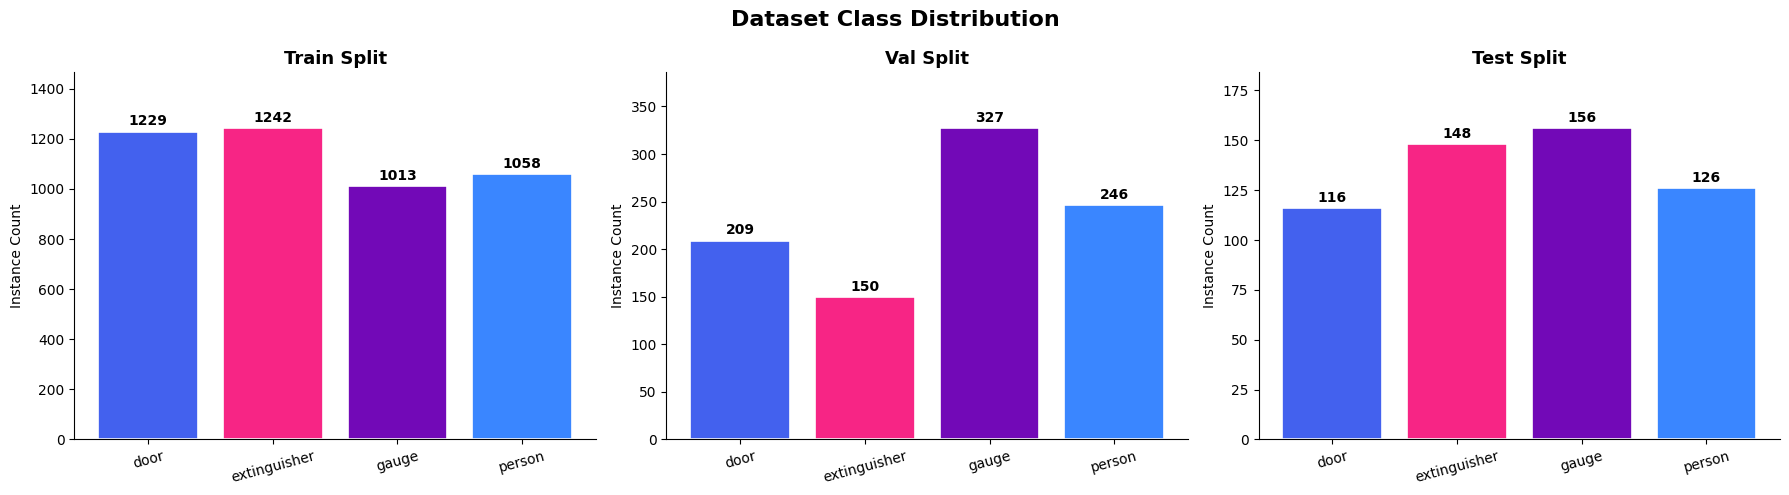


  Saved → eda_class_distribution.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = ['door', 'extinguisher', 'gauge', 'person']
COLORS      = ['#4361ee', '#f72585', '#7209b7', '#3a86ff']

def count_labels(label_dir):
    """Count class instances from YOLO label files."""
    counter = Counter()
    label_dir = Path(label_dir)
    if not label_dir.exists():
        return counter
    for f in label_dir.glob('*.txt'):
        for line in f.read_text().strip().splitlines():
            cls = int(line.split()[0])
            counter[cls] += 1
    return counter

def get_image_stats(img_dir):
    """Collect image widths and heights."""
    widths, heights = [], []
    for p in Path(img_dir).glob('*.*'):
        try:
            w, h = Image.open(p).size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass
    return widths, heights

# ── Class distribution ───────────────────────────────────────
train_counts = count_labels(DATASET_DIR / 'train' / 'labels')
val_counts   = count_labels(DATASET_DIR / 'valid' / 'labels')
test_counts  = count_labels(DATASET_DIR / 'test'  / 'labels')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')

for ax, (split, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]):
    values = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, values, color=COLORS, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{split} Split', fontsize=13, fontweight='bold')
    ax.set_ylabel('Instance Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.18 if values else 1)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(WORK_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Saved → eda_class_distribution.png')

Analysing image dimensions (train split)...


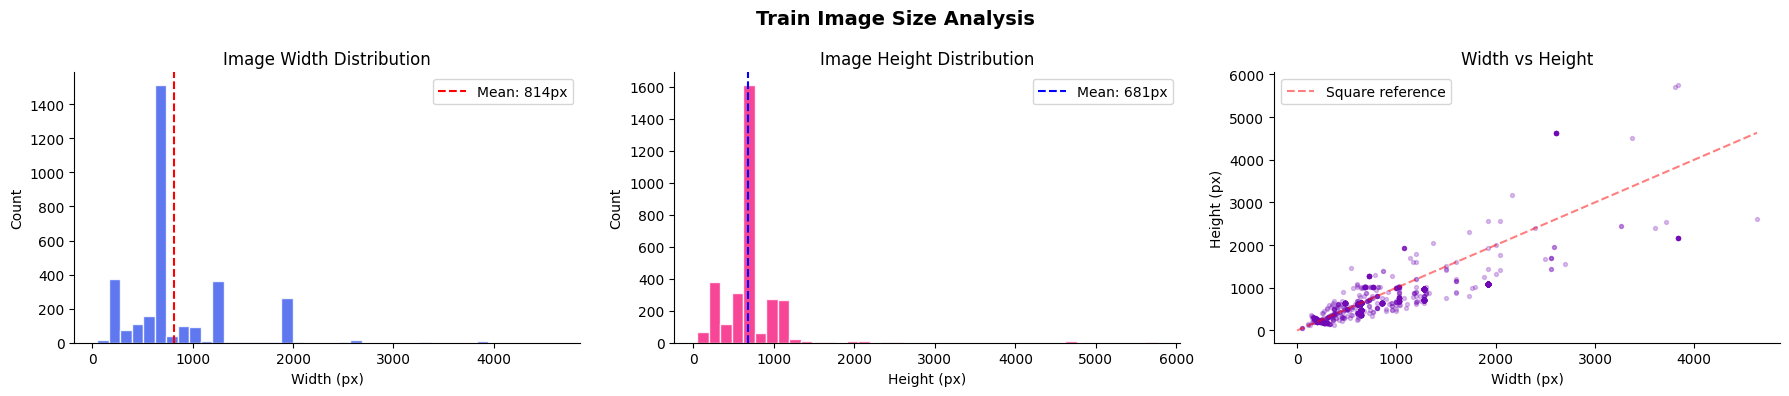

  Width  — min:50 max:4632 mean:814 median:640
  Height — min:50 max:5760 mean:681 median:640
  Saved → eda_image_sizes.png


In [13]:
# ── Image size distribution (train) ─────────────────────────
print('Analysing image dimensions (train split)...')
widths, heights = get_image_stats(DATASET_DIR / 'train' / 'images')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Train Image Size Analysis', fontsize=14, fontweight='bold')

axes[0].hist(widths,  bins=40, color='#4361ee', edgecolor='white', alpha=0.85)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].legend()

axes[1].hist(heights, bins=40, color='#f72585', edgecolor='white', alpha=0.85)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(heights), color='blue', linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.25, s=8, color='#7209b7')
axes[2].set_title('Width vs Height')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].plot([0, max(widths)], [0, max(widths)], 'r--', alpha=0.5, label='Square reference')
axes[2].legend()

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(WORK_DIR / 'eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Width  — min:{min(widths)} max:{max(widths)} mean:{np.mean(widths):.0f} median:{np.median(widths):.0f}')
print(f'  Height — min:{min(heights)} max:{max(heights)} mean:{np.mean(heights):.0f} median:{np.median(heights):.0f}')
print(f'  Saved → eda_image_sizes.png')

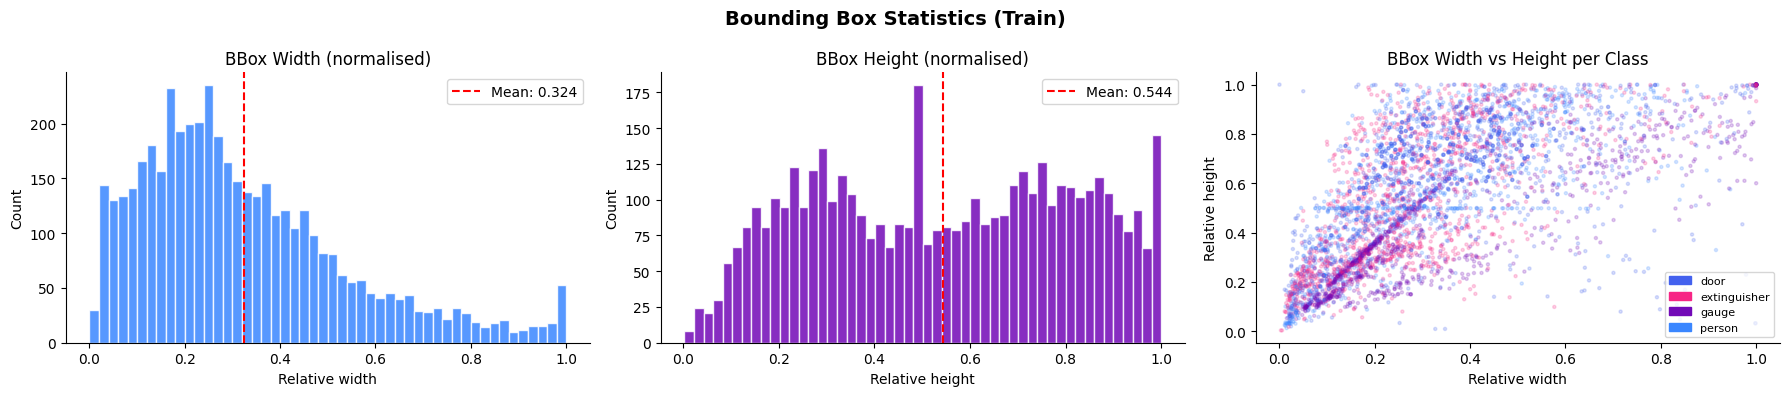

  Total train annotations: 4542
  Saved → eda_bbox_stats.png


In [14]:
# ── BBox size distribution from labels ───────────────────────
bw_list, bh_list, cls_list = [], [], []
for f in (DATASET_DIR / 'train' / 'labels').glob('*.txt'):
    for line in f.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            cls_list.append(int(parts[0]))
            bw_list.append(float(parts[3]))   # normalised width
            bh_list.append(float(parts[4]))   # normalised height

bw_arr = np.array(bw_list)
bh_arr = np.array(bh_list)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Bounding Box Statistics (Train)', fontsize=14, fontweight='bold')

axes[0].hist(bw_arr, bins=50, color='#3a86ff', edgecolor='white', alpha=0.85)
axes[0].set_title('BBox Width (normalised)')
axes[0].set_xlabel('Relative width')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(bw_arr), color='red', linestyle='--', label=f'Mean: {np.mean(bw_arr):.3f}')
axes[0].legend()

axes[1].hist(bh_arr, bins=50, color='#7209b7', edgecolor='white', alpha=0.85)
axes[1].set_title('BBox Height (normalised)')
axes[1].set_xlabel('Relative height')
axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(bh_arr), color='red', linestyle='--', label=f'Mean: {np.mean(bh_arr):.3f}')
axes[1].legend()

axes[2].scatter(bw_arr, bh_arr, c=[COLORS[c % 4] for c in cls_list], alpha=0.2, s=5)
axes[2].set_title('BBox Width vs Height per Class')
axes[2].set_xlabel('Relative width')
axes[2].set_ylabel('Relative height')
patches = [mpatches.Patch(color=COLORS[i], label=CLASS_NAMES[i]) for i in range(4)]
axes[2].legend(handles=patches, fontsize=8)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(WORK_DIR / 'eda_bbox_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Total train annotations: {len(bw_list)}')
print(f'  Saved → eda_bbox_stats.png')

---
## 🏋️ Cell 5 — Train YOLO26s
> **YOLO26s** — latest Ultralytics model (Jan 2026):  
> • Native NMS-free end-to-end architecture (no DFL)  
> • MuSGD optimizer (hybrid SGD + Muon, auto-selected for long runs)  
> • `device=-1` → idle GPU auto-selection  
> • ProgLoss + STAL for better small-object detection  
> Reference: https://docs.ultralytics.com/modes/train/#idle-gpu-training

In [ ]:
from ultralytics import YOLO

# ── Load YOLO26s pretrained weights ──────────────────────────
# yolo26s.pt will be auto-downloaded (~19 MB) on first run
model = YOLO('yolo26s.pt')

print('Starting YOLO26s training...')
print(f'  Model      : YOLO26s (NMS-free, MuSGD)')
print(f'  Output dir : {RUN_DIR / EXP_NAME}')
print(f'  Device     : -1 (idle GPU auto-selection)')
print('=' * 60)

# Windows multiprocessing guard
if __name__ == '__main__' or True:   # always true in Jupyter
    results = model.train(
        data        = str(DATA_YAML),

        # ── Core ──────────────────────────────────────────────
        epochs      = 100,
        imgsz       = 960,
        batch       = 8,          # reduce to 4 if GPU OOM
        device      = -1,         # idle GPU auto-selection
        workers     = 0,          # 0 = no multiprocessing (safe on Windows)
        cache       = False,

        # ── Optimizer ─────────────────────────────────────────
        # 'auto' → MuSGD for long runs (>10k iterations), AdamW for short
        # MuSGD = hybrid SGD + Muon, recommended for YOLO26 100-epoch runs
        optimizer     = 'auto',
        lr0           = 0.01,
        lrf           = 0.01,
        momentum      = 0.937,
        weight_decay  = 0.0005,

        # ── Augmentation ──────────────────────────────────────
        mosaic    = 1.0,
        scale     = 0.5,
        fliplr    = 0.5,
        translate = 0.1,

        # ── Mixed precision ───────────────────────────────────
        amp         = True,       # set False if you see NaN losses

        # ── Saving ────────────────────────────────────────────
        project     = str(RUN_DIR),
        name        = EXP_NAME,
        save        = True,
        save_period = 5,          # checkpoint every 5 epochs
        exist_ok    = True,

        # ── Patience & verbose ────────────────────────────────
        patience    = 40,
        plots       = True,
        verbose     = True,
    )

print('\n' + '=' * 60)
print('✅ TRAINING COMPLETE')
print(f"  mAP50    : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95 : {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print('=' * 60)

Starting YOLO26s training...
  Model      : YOLO26s (NMS-free, MuSGD)
  Output dir : C:\Users\Rebecca Fernando\Desktop\Dinethra\Yolov11s\runs\yolo26s_exp
  Device     : -1 (idle GPU auto-selection)
Searching for 1 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0]
Ultralytics 8.4.38  Python-3.10.11 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Rebecca Fernando\Desktop\Dinethra\Yolov11s\data_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, f

---
## 📈 Cell 6 — Training Curves (Loss & Metrics)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

EXP_DIR    = RUN_DIR / EXP_NAME
CSV_PATH   = EXP_DIR / 'results.csv'

if not CSV_PATH.exists():
    raise FileNotFoundError(f'results.csv not found at {CSV_PATH}\nRun the training cell first!')

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]   # strip whitespace
print('Columns in results.csv:', df.columns.tolist())
df.head(3)

In [ ]:
# ── Helper to safely get a column ───────────────────────────
def get_col(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return df[c].values
    return None

epochs = df['epoch'].values if 'epoch' in df.columns else np.arange(1, len(df)+1)

# ── Figure 1: Loss curves ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('YOLO26s — Training & Validation Losses', fontsize=16, fontweight='bold')

# Note: YOLO26s removes DFL — only box_loss and cls_loss remain
loss_pairs = [
    ('Box Loss',  'train/box_loss',  'val/box_loss'),
    ('Cls Loss',  'train/cls_loss',  'val/cls_loss'),
    ('DFL Loss',  'train/dfl_loss',  'val/dfl_loss'),  # may be absent in YOLO26
]
metric_pairs = [
    ('Precision',  'metrics/precision(B)',  None),
    ('Recall',     'metrics/recall(B)',     None),
    ('mAP50',      'metrics/mAP50(B)',      'metrics/mAP50-95(B)'),
]

for ax, (title, train_key, val_key) in zip(axes[0], loss_pairs):
    train_vals = get_col(df, train_key)
    val_vals   = get_col(df, val_key)
    if train_vals is not None:
        ax.plot(epochs, train_vals, label='Train', color='#4361ee', linewidth=1.8)
    if val_vals is not None:
        ax.plot(epochs, val_vals,   label='Val',   color='#f72585', linewidth=1.8, linestyle='--')
    ax.set_title(title + (' (N/A — YOLO26 removed DFL)' if 'dfl' in train_key and train_vals is None else ''),
                 fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

for ax, (title, key1, key2) in zip(axes[1], metric_pairs):
    vals1 = get_col(df, key1)
    if vals1 is not None:
        ax.plot(epochs, vals1, label=title, color='#3a86ff', linewidth=1.8)
    if key2:
        vals2 = get_col(df, key2)
        if vals2 is not None:
            ax.plot(epochs, vals2, label='mAP50-95', color='#7209b7', linewidth=1.8, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Value')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(WORK_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved → training_curves.png')

In [ ]:
# ── Figure 2: LR schedule ────────────────────────────────────
lr_cols = [c for c in df.columns if 'lr' in c.lower()]

if lr_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    lr_colors = ['#4361ee', '#f72585', '#3a86ff']
    for i, col in enumerate(lr_cols):
        ax.plot(epochs, df[col].values, label=col, color=lr_colors[i % len(lr_colors)], linewidth=1.8)
    ax.set_title('Learning Rate Schedule (MuSGD auto-selected)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved → lr_schedule.png')
else:
    print('  No LR columns found in results.csv')

---
## ✅ Cell 7 — Full Validation on Best Weights

In [ ]:
WEIGHTS_DIR = EXP_DIR / 'weights'
BEST_PT     = WEIGHTS_DIR / 'best.pt'
LAST_PT     = WEIGHTS_DIR / 'last.pt'

if not BEST_PT.exists():
    raise FileNotFoundError(f'best.pt not found at {BEST_PT}\nCheck the training ran successfully.')

best_model = YOLO(str(BEST_PT))

val_results = best_model.val(
    data    = str(DATA_YAML),
    imgsz   = 960,
    device  = -1,
    workers = 0,
    plots   = True,      # saves confusion matrix, PR curve, etc.
    save_json = False,
    name    = 'val_best',
    project = str(RUN_DIR),
    exist_ok = True,
)

print('\n' + '=' * 60)
print('VALIDATION RESULTS — best.pt  (YOLO26s)')
print('=' * 60)
rd = val_results.results_dict
print(f"  mAP50     : {rd.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP50-95  : {rd.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision : {rd.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall    : {rd.get('metrics/recall(B)', 0):.4f}")
print(f"  Speed     : pre={val_results.speed.get('preprocess',0):.1f}ms  "
      f"infer={val_results.speed.get('inference',0):.1f}ms  "
      f"post={val_results.speed.get('postprocess',0):.1f}ms")
print('=' * 60)

---
## 📊 Cell 8 — Class-wise Performance Table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Extract per-class metrics from val_results ───────────────
try:
    ap50    = val_results.box.ap50           # shape: (num_classes,)
    ap      = val_results.box.ap             # mAP50-95 per class
    p_vals  = val_results.box.p              # precision per class
    r_vals  = val_results.box.r              # recall per class
    names   = CLASS_NAMES

    rows = []
    for i, name in enumerate(names):
        rows.append({
            'Class'  : name,
            'P'      : round(float(p_vals[i]), 4),
            'R'      : round(float(r_vals[i]), 4),
            'mAP50'  : round(float(ap50[i]),   4),
            'mAP50-95': round(float(ap[i]),    4),
        })

    df_cls = pd.DataFrame(rows)

    # Overall row
    df_cls.loc[len(df_cls)] = {
        'Class'   : 'ALL (mean)',
        'P'       : round(float(p_vals.mean()),  4),
        'R'       : round(float(r_vals.mean()),  4),
        'mAP50'   : round(float(ap50.mean()),    4),
        'mAP50-95': round(float(ap.mean()),      4),
    }

    print('\nClass-wise Performance Table (YOLO26s):')
    print(df_cls.to_string(index=False))

    # ── Bar chart ─────────────────────────────────────────────
    x = np.arange(len(names))
    w = 0.2
    fig, ax = plt.subplots(figsize=(12, 5))

    bars_p   = ax.bar(x - 1.5*w, [float(p_vals[i]) for i in range(len(names))], w, label='Precision', color='#4361ee')
    bars_r   = ax.bar(x - 0.5*w, [float(r_vals[i]) for i in range(len(names))], w, label='Recall',    color='#f72585')
    bars_ap  = ax.bar(x + 0.5*w, [float(ap50[i])   for i in range(len(names))], w, label='mAP50',     color='#3a86ff')
    bars_ap2 = ax.bar(x + 1.5*w, [float(ap[i])     for i in range(len(names))], w, label='mAP50-95',  color='#7209b7')

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_title('Per-Class Performance — YOLO26s best.pt', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(WORK_DIR / 'classwise_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved → classwise_performance.png')

    df_cls.to_csv(WORK_DIR / 'classwise_metrics.csv', index=False)
    print('  Saved → classwise_metrics.csv')

except Exception as e:
    print(f'Could not extract per-class metrics: {e}')
    print('Check val_results object attrs:', dir(val_results))

---
## 🟦 Cell 9 — Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm_path      = RUN_DIR / 'val_best' / 'confusion_matrix.png'
cm_norm_path = RUN_DIR / 'val_best' / 'confusion_matrix_normalized.png'

for path, title in [(cm_path, 'Confusion Matrix (Raw)'),
                    (cm_norm_path, 'Confusion Matrix (Normalised)')]:
    if path.exists():
        img = plt.imread(str(path))
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.show()
        print(f'  Displayed: {path.name}')
    else:
        print(f'  File not found: {path}')

# ── Manual normalised heatmap ─────────────────────────────────
try:
    import seaborn as sns

    cm_raw = val_results.confusion_matrix.matrix   # shape (nc+1, nc+1)
    nc = len(CLASS_NAMES)
    cm_display = cm_raw[:nc, :nc]                  # remove background row/col

    row_sums = cm_display.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm_display / row_sums, 0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confusion Matrices — YOLO26s best.pt', fontsize=14, fontweight='bold')

    sns.heatmap(cm_display, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title('Raw Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
                vmin=0, vmax=1)
    axes[1].set_title('Row-Normalised')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(WORK_DIR / 'confusion_matrix_custom.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved → confusion_matrix_custom.png')
except Exception as e:
    print(f'  Could not build manual confusion matrix: {e}')

---
## 📉 Cell 10 — PR Curve, F1-Confidence Curve, mAP Radar

In [ ]:
# ── Display YOLO auto-generated curves ───────────────────────
curve_files = {
    'PR Curve'     : RUN_DIR / 'val_best' / 'PR_curve.png',
    'F1 Curve'     : RUN_DIR / 'val_best' / 'F1_curve.png',
    'P Curve'      : RUN_DIR / 'val_best' / 'P_curve.png',
    'R Curve'      : RUN_DIR / 'val_best' / 'R_curve.png',
}

found = {k: v for k, v in curve_files.items() if v.exists()}
if found:
    fig, axes = plt.subplots(1, len(found), figsize=(6*len(found), 5))
    if len(found) == 1:
        axes = [axes]
    for ax, (title, path) in zip(axes, found.items()):
        img = plt.imread(str(path))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=11, fontweight='bold')
    plt.suptitle('Detection Performance Curves — YOLO26s', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'performance_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved → performance_curves.png')
else:
    print('  Curve images not found. Run validation with plots=True first.')

In [ ]:
# ── Spider / Radar chart of per-class mAP50 ─────────────────
try:
    ap50_vals = [float(ap50[i]) for i in range(len(CLASS_NAMES))]
    N = len(CLASS_NAMES)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    vals   = ap50_vals + [ap50_vals[0]]   # close polygon
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, vals, 'o-', linewidth=2, color='#4361ee')
    ax.fill(angles, vals, alpha=0.25, color='#4361ee')
    ax.set_thetagrids(np.degrees(angles[:-1]), CLASS_NAMES, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
    ax.set_title('mAP50 per Class — YOLO26s Radar', fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(WORK_DIR / 'radar_map50.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Saved → radar_map50.png')
except Exception as e:
    print(f'  Radar chart error: {e}')

---
## 🧪 Cell 11 — Test Split Evaluation

In [ ]:
import yaml

# Build a test-only yaml dynamically
test_yaml_path = WORK_DIR / 'data_test.yaml'
test_yaml_content = {
    'path' : str(DATASET_DIR).replace('\\', '/'),
    'train': 'train/images',
    'val'  : 'test/images',    # point val → test split
    'test' : 'test/images',
    'nc'   : 4,
    'names': CLASS_NAMES,
}
with open(test_yaml_path, 'w') as f:
    yaml.dump(test_yaml_content, f, default_flow_style=False)

test_results = best_model.val(
    data    = str(test_yaml_path),
    imgsz   = 960,
    split   = 'val',           # ultralytics uses 'val' key even for test
    device  = -1,
    workers = 0,
    plots   = True,
    name    = 'test_best',
    project = str(RUN_DIR),
    exist_ok = True,
)

print('\n' + '=' * 60)
print('TEST SPLIT RESULTS — YOLO26s best.pt')
print('=' * 60)
rd = test_results.results_dict
print(f"  mAP50     : {rd.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP50-95  : {rd.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision : {rd.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall    : {rd.get('metrics/recall(B)', 0):.4f}")
print('=' * 60)

---
## 🖼️ Cell 12 — Visual Predictions on Sample Test Images

In [ ]:
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

test_img_dir = DATASET_DIR / 'test' / 'images'
all_test_imgs = list(test_img_dir.glob('*.*'))
sample_imgs   = random.sample(all_test_imgs, min(9, len(all_test_imgs)))

inference_results = best_model.predict(
    source = [str(p) for p in sample_imgs],
    imgsz  = 960,
    conf   = 0.25,
    device = -1,
    verbose= False,
)

# ── Plot grid ────────────────────────────────────────────────
n_cols = 3
n_rows = int(np.ceil(len(inference_results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

fig.suptitle('YOLO26s — Sample Test Predictions (conf ≥ 0.25)',
             fontsize=15, fontweight='bold')

for i, r in enumerate(inference_results):
    annotated = r.plot()  # BGR numpy from ultralytics
    annotated_rgb = annotated[:, :, ::-1]
    axes[i].imshow(annotated_rgb)
    axes[i].axis('off')
    n_det = len(r.boxes) if r.boxes else 0
    axes[i].set_title(f'{Path(r.path).name}\n{n_det} detection(s)', fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(WORK_DIR / 'sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('  Saved → sample_predictions.png')

In [ ]:
# ── Run full test-split predict & save to disk ────────────────
predict_out = RUN_DIR / 'predict_test'

best_model.predict(
    source  = str(test_img_dir),
    imgsz   = 960,
    conf    = 0.25,
    device  = -1,
    save    = True,
    save_txt= True,
    save_conf=True,
    project = str(RUN_DIR),
    name    = 'predict_test',
    exist_ok= True,
    verbose = False,
)
print(f'  All test predictions saved → {RUN_DIR / "predict_test"}')

---
## 📦 Cell 13 — Checkpoint Browser (Every-5-Epoch Weights)

In [ ]:
# List all saved checkpoints
ckpt_files = sorted(WEIGHTS_DIR.glob('epoch*.pt'))

print(f'Checkpoint directory: {WEIGHTS_DIR}')
print(f'Total checkpoints (epoch*.pt): {len(ckpt_files)}')
print(f'Best weights  : {"found" if BEST_PT.exists() else "MISSING"}')
print(f'Last weights  : {"found" if LAST_PT.exists() else "MISSING"}')
print()

rows = []
for f in ckpt_files:
    size_mb = f.stat().st_size / 1e6
    rows.append({'file': f.name, 'size_MB': round(size_mb, 1)})
for r in rows:
    print(f"  {r['file']:20s}  {r['size_MB']:5.1f} MB")
if not rows:
    print('  No epoch checkpoints found. (save_period=5 saves epoch5.pt, epoch10.pt, ...)')

---
## 📋 Cell 14 — Full Training Summary Report

In [ ]:
import json
from datetime import datetime

df_res = pd.read_csv(CSV_PATH)
df_res.columns = [c.strip() for c in df_res.columns]

def get_col_name(df, *candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

map50_col = get_col_name(df_res, 'metrics/mAP50(B)')
map95_col = get_col_name(df_res, 'metrics/mAP50-95(B)')

if map50_col:
    best_row   = df_res.loc[df_res[map50_col].idxmax()]
    best_ep    = int(best_row.get('epoch', -1))
    best_map50 = float(best_row[map50_col])
    best_map95 = float(best_row[map95_col]) if map95_col else float('nan')
else:
    best_ep = best_map50 = best_map95 = 'N/A'

summary = {
    'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model'         : 'YOLO26s',
    'dataset'       : str(DATASET_DIR),
    'classes'       : CLASS_NAMES,
    'total_epochs'  : len(df_res),
    'best_epoch'    : best_ep,
    'best_mAP50'    : best_map50,
    'best_mAP50-95' : best_map95,
    'val_mAP50'     : val_results.results_dict.get('metrics/mAP50(B)', 'N/A'),
    'val_mAP50-95'  : val_results.results_dict.get('metrics/mAP50-95(B)', 'N/A'),
    'val_Precision' : val_results.results_dict.get('metrics/precision(B)', 'N/A'),
    'val_Recall'    : val_results.results_dict.get('metrics/recall(B)', 'N/A'),
    'test_mAP50'    : test_results.results_dict.get('metrics/mAP50(B)', 'N/A'),
    'test_mAP50-95' : test_results.results_dict.get('metrics/mAP50-95(B)', 'N/A'),
    'weights_dir'   : str(WEIGHTS_DIR),
    'best_pt'       : str(BEST_PT),
    'last_pt'       : str(LAST_PT),
    'hyperparams': {
        'epochs': 100, 'imgsz': 960, 'batch': 8,
        'optimizer': 'auto (MuSGD for long runs)', 'lr0': 0.01, 'lrf': 0.01,
        'momentum': 0.937, 'weight_decay': 0.0005,
        'device': '-1 (idle GPU auto-selection)',
        'mosaic': 1.0, 'scale': 0.5, 'fliplr': 0.5,
        'translate': 0.1, 'save_period': 5, 'patience': 40,
        'nms_free': True, 'dfl_removed': True,
    }
}

summary_path = WORK_DIR / 'training_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('\n' + '=' * 60)
print('  YOLO26s TRAINING SUMMARY')
print('=' * 60)
for k, v in summary.items():
    if k != 'hyperparams':
        print(f'  {k:20s}: {v}')
print('  Hyperparameters:')
for k, v in summary['hyperparams'].items():
    print(f'    {k:22s}: {v}')
print('=' * 60)
print(f'  Saved → training_summary.json')

In [ ]:
# ── Visual summary card ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

rd_val  = val_results.results_dict
rd_test = test_results.results_dict

card_text = [
    ('Model',        'YOLO26s  (NMS-free · MuSGD · ProgLoss)'),
    ('Dataset',      '4-class Visual Inspection'),
    ('Classes',      ', '.join(CLASS_NAMES)),
    ('Image Size',   '960 × 960'),
    ('Epochs',       f'{len(df_res)} / 100'),
    ('Best Epoch',   str(best_ep)),
    ('Device',       '-1 (Idle GPU auto-selection)'),
    ('─' * 30, '─' * 20),
    ('Val mAP50',    f"{rd_val.get('metrics/mAP50(B)', 0):.4f}"),
    ('Val mAP50-95', f"{rd_val.get('metrics/mAP50-95(B)', 0):.4f}"),
    ('Val Precision',f"{rd_val.get('metrics/precision(B)', 0):.4f}"),
    ('Val Recall',   f"{rd_val.get('metrics/recall(B)', 0):.4f}"),
    ('─' * 30, '─' * 20),
    ('Test mAP50',   f"{rd_test.get('metrics/mAP50(B)', 0):.4f}"),
    ('Test mAP50-95',f"{rd_test.get('metrics/mAP50-95(B)', 0):.4f}"),
    ('─' * 30, '─' * 20),
    ('Optimizer',    'auto → MuSGD  lr=0.01  momentum=0.937'),
    ('Architecture', 'End-to-end NMS-free (no DFL)'),
    ('Save Period',  'Every 5 epochs'),
]

y = 0.97
for label, value in card_text:
    is_sep = label.startswith('─')
    color = '#888888' if is_sep else '#000000'
    weight = 'normal' if is_sep else 'bold' if label in ('Model','Val mAP50','Test mAP50') else 'normal'
    ax.text(0.05, y, label, transform=ax.transAxes,
            fontsize=10, color=color, fontweight=weight, va='top')
    ax.text(0.50, y, value, transform=ax.transAxes,
            fontsize=10, color='#2b4ef7' if 'mAP' in label else color, va='top')
    y -= 0.058 if not is_sep else 0.025

ax.set_facecolor('#f0f4ff')
fig.patch.set_facecolor('#f0f4ff')
ax.set_title('YOLO26s — Training Summary Card', fontsize=14,
             fontweight='bold', pad=12, color='#1a1a2e')

plt.tight_layout()
plt.savefig(WORK_DIR / 'summary_card.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4ff')
plt.show()
print('  Saved → summary_card.png')

---
## ♻️ Cell 15 — Resume Interrupted Training
> Run this cell **only** if training was cut short. It will pick up from the last checkpoint.
> Reference: https://docs.ultralytics.com/modes/train/#resuming-interrupted-trainings

In [ ]:
# ── Resume from last.pt ───────────────────────────────────────
RESUME = False  # ← set True to resume

if RESUME:
    if not LAST_PT.exists():
        raise FileNotFoundError(f'last.pt not found: {LAST_PT}')

    print(f'Resuming YOLO26s training from: {LAST_PT}')
    resume_model = YOLO(str(LAST_PT))
    resume_model.train(resume=True)
    print('\n✅ Training resumed and complete!')
else:
    print('Resume is set to False. Flip RESUME=True if needed.')
    print(f'  last.pt location: {LAST_PT}')
    print(f'  Exists          : {LAST_PT.exists()}')

---
## 📂 Cell 16 — Output File Map

In [ ]:
print('=' * 65)
print('  ALL SAVED FILES  (YOLO26s Run)')
print('=' * 65)

output_map = [
    ('data_local.yaml',            'Dataset config for local training'),
    ('eda_class_distribution.png', 'Class instance counts per split'),
    ('eda_image_sizes.png',        'Image dimension distributions'),
    ('eda_bbox_stats.png',         'Bounding box size distributions'),
    ('training_curves.png',        'Loss & metric curves over epochs'),
    ('lr_schedule.png',            'Learning rate schedule (MuSGD)'),
    ('classwise_performance.png',  'Per-class P/R/mAP50/mAP95 bars'),
    ('classwise_metrics.csv',      'Per-class metrics table'),
    ('confusion_matrix_custom.png','Raw + normalised confusion matrix'),
    ('performance_curves.png',     'PR, F1, P, R curves'),
    ('radar_map50.png',            'Radar chart of per-class mAP50'),
    ('sample_predictions.png',     '9-image prediction mosaic'),
    ('training_summary.json',      'Full run metadata & metrics'),
    ('summary_card.png',           'Visual summary card'),
    (f'runs/{EXP_NAME}/weights/best.pt', 'Best checkpoint'),
    (f'runs/{EXP_NAME}/weights/last.pt', 'Last checkpoint'),
    (f'runs/{EXP_NAME}/weights/epoch*.pt','Every-5-epoch checkpoints'),
    (f'runs/{EXP_NAME}/results.csv',      'Per-epoch metrics log'),
    ('runs/val_best/',             'Validation plots & labels'),
    ('runs/test_best/',            'Test evaluation plots & labels'),
    ('runs/predict_test/',         'All test images with drawn boxes'),
]

for fname, desc in output_map:
    full = WORK_DIR / fname
    status = '✅' if full.exists() else '📝'
    print(f'  {status} {fname:45s} {desc}')

print('=' * 65)
print('  YOLO26s Notebook complete! 🎉')